In [63]:
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn as sk
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
from xgboost import plot_tree, plot_importance


from utils import scale_data

RANDOM_STATE = 36


## Importing Data

In [64]:
df = sns.load_dataset("titanic")
print(df[:5].to_string())
print(df.shape)

   survived  pclass     sex   age  sibsp  parch     fare embarked  class    who  adult_male deck  embark_town alive  alone
0         0       3    male  22.0      1      0   7.2500        S  Third    man        True  NaN  Southampton    no  False
1         1       1  female  38.0      1      0  71.2833        C  First  woman       False    C    Cherbourg   yes  False
2         1       3  female  26.0      0      0   7.9250        S  Third  woman       False  NaN  Southampton   yes   True
3         1       1  female  35.0      1      0  53.1000        S  First  woman       False    C  Southampton   yes  False
4         0       3    male  35.0      0      0   8.0500        S  Third    man        True  NaN  Southampton    no   True
(891, 15)


In [65]:
print(df.dtypes)
print(type(df))

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object
<class 'pandas.DataFrame'>


## Cleaning Data

## Removing Irrelevant Data

In [66]:
df = df.drop('alive', axis='columns')


## Fixing NaNs

In [67]:
var = [feature for feature in df.columns
       if df[feature].dtype in ['category', 'string'] ]

for i in range(len(var)):
    cols = var[i]
    
    if df[cols].dtypes == 'category':
        
        df[cols] = df[cols].cat.add_categories('Unknown')
        
    df[cols] = df[cols].fillna('Unknown')


In [68]:
# print("Boolean DataFrame:\n", df.isnull())
print(df.dtypes)
print("\nCount of NaN in each column:\n", df.isnull().sum())

survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alone              bool
dtype: object

Count of NaN in each column:
 survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         0
class            0
who              0
adult_male       0
deck             0
embark_town      0
alone            0
dtype: int64


## Setting median for NaN age

In [69]:
df['age'] = df['age'].fillna(
    df.groupby(['sex', 'pclass'])['age'].transform('median')
)
print(df.isnull().sum())

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alone          0
dtype: int64


## One-Hot Encoding

In [70]:
df = pd.get_dummies(df, columns=var, drop_first=True)

In [71]:
print(df.shape)
print(df.columns.to_list())

(891, 27)
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare', 'adult_male', 'alone', 'sex_male', 'embarked_Q', 'embarked_S', 'embarked_Unknown', 'class_Second', 'class_Third', 'class_Unknown', 'who_man', 'who_woman', 'deck_B', 'deck_C', 'deck_D', 'deck_E', 'deck_F', 'deck_G', 'deck_Unknown', 'embark_town_Queenstown', 'embark_town_Southampton', 'embark_town_Unknown']


## Spliting Target

In [72]:

var = [feature for feature in df.columns if feature != 'survived']

In [73]:
x_train, _x, y_train, _y = train_test_split(df[var], df['survived'], test_size=0.3, random_state=RANDOM_STATE)
x_cv, x_test, y_cv, y_test = train_test_split(_x, _y, test_size=0.5, random_state=RANDOM_STATE)

print(x_train.shape, x_cv.shape, x_test.shape)


(623, 26) (134, 26) (134, 26)


## Scaling Data

In [74]:

scale_data(x_train, x_cv, x_test)

## Training Model


In [75]:
xgb_model = XGBClassifier(random_state = RANDOM_STATE)
xgb_model.fit(x_train, y_train)

yhat_train = xgb_model.predict(x_train)
print(xgb_model.score(x_train, y_train))


0.9823434991974318


# Fixing High Variance

## Tuning hyperparams

In [76]:
best_params = {}

### With Max Depth

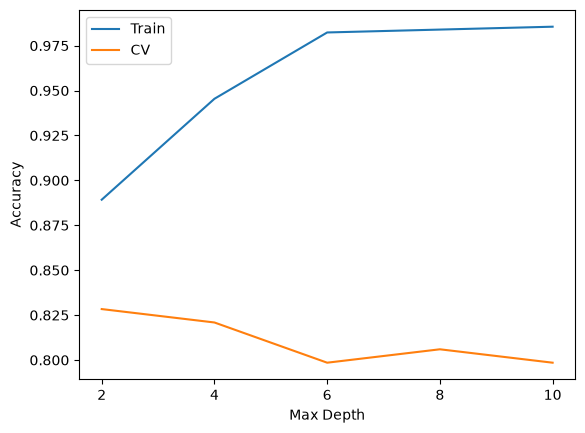

In [77]:
max_depths = [2, 4, 6, 8, 10]
accuracy_train = []
accuracy_cv = []

temp_accuracy = 0
temp_depth = 0
for depth in max_depths:
    xgb_model = XGBClassifier(max_depth = depth, random_state = RANDOM_STATE)
    xgb_model.fit(x_train, y_train)
    
    yhat_train = xgb_model.predict(x_train)
    yhat_cv = xgb_model.predict(x_cv)
    
    model_train_accuracy = accuracy_score(y_train, yhat_train)
    model_cv_accuracy =  accuracy_score(y_cv, yhat_cv)
    
    accuracy_train.append(model_train_accuracy)
    accuracy_cv.append(model_cv_accuracy)
    
    #? Adding the best Result to the best_params Object
    if model_cv_accuracy >= temp_accuracy:
        temp_accuracy = model_cv_accuracy
        temp_depth = depth

best_params['max_depth'] = temp_depth
    
plt.plot(accuracy_train)
plt.plot(accuracy_cv)
plt.xticks(ticks=range(len(max_depths)), labels=max_depths)
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend(['Train', 'CV'])



### With Learning Rate

[0.92776886035313, 0.9823434991974318, 0.9101123595505618, 0.985553772070626, 0.6260032102728732] 
 [0.8059701492537313, 0.7985074626865671, 0.8134328358208955, 0.7985074626865671, 0.5522388059701493]
{'max_depth': 2, 'learning_rate': 0.05}


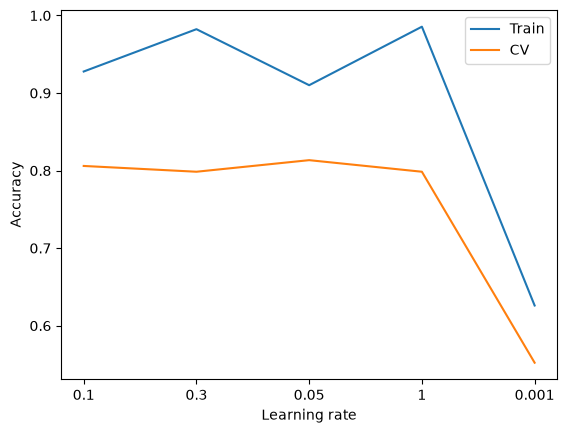

In [78]:
learning_rates = [0.1, 0.3, 0.05, 1, 0.001]

accuracy_train = []
accuracy_cv = []

temp_accuracy = 0
temp_rate = 0
for rate in learning_rates:
    xgb_model = XGBClassifier(learning_rate = rate, random_state = RANDOM_STATE)
    xgb_model.fit(x_train, y_train)
    
    yhat_train = xgb_model.predict(x_train)
    yhat_cv = xgb_model.predict(x_cv)
    
    model_train_accuracy = accuracy_score(y_train, yhat_train)
    model_cv_accuracy =  accuracy_score(y_cv, yhat_cv)
    
    accuracy_train.append(model_train_accuracy)
    accuracy_cv.append(model_cv_accuracy)
        
    #? Adding the best Result to the best_params Object
    if model_cv_accuracy >= temp_accuracy:
        temp_accuracy = model_cv_accuracy
        temp_rate = rate

best_params['learning_rate'] = temp_rate

plt.plot(accuracy_train)
plt.plot(accuracy_cv)
plt.xticks(ticks=range(len(learning_rates)), labels=learning_rates)
plt.xlabel('Learning rate')
plt.ylabel('Accuracy')
plt.legend(['Train', 'CV'])

print(accuracy_train, '\n',accuracy_cv)

print(best_params)


### With N-estimators

[0.8972712680577849, 0.956661316211878, 0.9823434991974318, 0.985553772070626, 0.985553772070626] 
 [0.8208955223880597, 0.7985074626865671, 0.7985074626865671, 0.7985074626865671, 0.7910447761194029]
{'max_depth': 2, 'learning_rate': 0.05, 'n_estimator': 10}


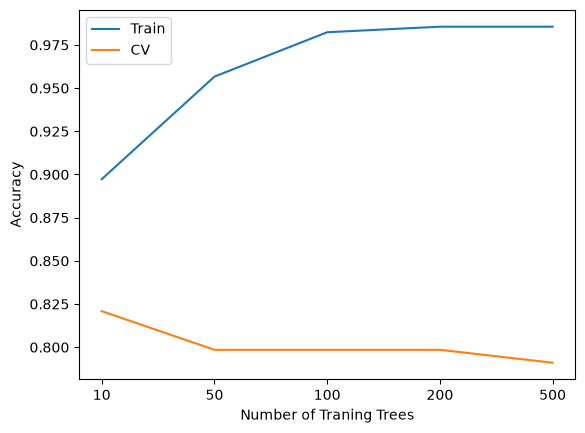

In [79]:
estimators = [10, 50, 100, 200, 500]

accuracy_train = []
accuracy_cv = []

temp_accuracy = 0
temp_sample = 0
for estimator in estimators:
    xgb_model = XGBClassifier(n_estimators = estimator, random_state = RANDOM_STATE)
    xgb_model.fit(x_train, y_train)
    
    yhat_train = xgb_model.predict(x_train)
    yhat_cv = xgb_model.predict(x_cv)
    
    model_train_accuracy = accuracy_score(y_train, yhat_train)
    model_cv_accuracy =  accuracy_score(y_cv, yhat_cv)
    
    accuracy_train.append(model_train_accuracy)
    accuracy_cv.append(model_cv_accuracy)
        
    #? Adding the best Result to the best_params Object
    if model_cv_accuracy >= temp_accuracy:
        temp_accuracy = model_cv_accuracy
        temp_sample = estimator

best_params['n_estimator'] = temp_sample

plt.plot(accuracy_train)
plt.plot(accuracy_cv)
plt.xticks(ticks=range(len(estimators)), labels=estimators)
plt.xlabel('Number of Traning Trees')
plt.ylabel('Accuracy')
plt.legend(['Train', 'CV'])

print(accuracy_train, '\n',accuracy_cv)

print(best_params)


## With Subsamples

[0.8956661316211878, 0.9614767255216693, 0.9743178170144462, 0.9823434991974318, 0.9823434991974318] 
 [0.8432835820895522, 0.8059701492537313, 0.8134328358208955, 0.7686567164179104, 0.7985074626865671]
{'max_depth': 2, 'learning_rate': 0.05, 'n_estimator': 10, 'subsample': 0.2}


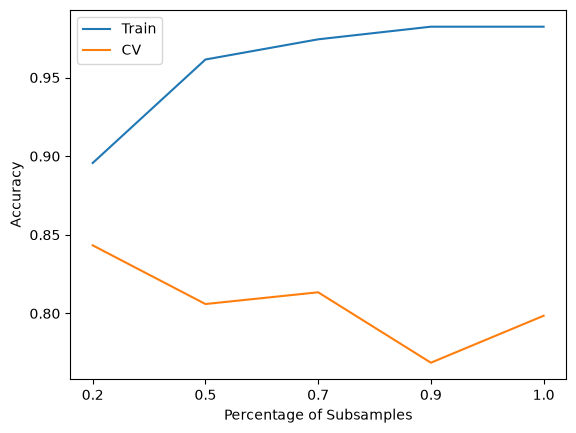

In [80]:
subsamples = [0.2, 0.5, 0.7, 0.9, 1.0]

accuracy_train = []
accuracy_cv = []

temp_accuracy = 0
temp_sample = 0
for sample in subsamples:
    xgb_model = XGBClassifier(subsample = sample, random_state = RANDOM_STATE)
    xgb_model.fit(x_train, y_train)
    
    yhat_train = xgb_model.predict(x_train)
    yhat_cv = xgb_model.predict(x_cv)
    
    model_train_accuracy = accuracy_score(y_train, yhat_train)
    model_cv_accuracy =  accuracy_score(y_cv, yhat_cv)
    
    accuracy_train.append(model_train_accuracy)
    accuracy_cv.append(model_cv_accuracy)
        
    #? Adding the best Result to the best_params Object
    if model_cv_accuracy >= temp_accuracy:
        temp_accuracy = model_cv_accuracy
        temp_sample = sample

best_params['subsample'] = temp_sample

plt.plot(accuracy_train)
plt.plot(accuracy_cv)
plt.xticks(ticks=range(len(subsamples)), labels=subsamples)
plt.xlabel('Percentage of Subsamples')
plt.ylabel('Accuracy')
plt.legend(['Train', 'CV'])

print(accuracy_train, '\n',accuracy_cv)

print(best_params)


In [81]:
print(best_params)

{'max_depth': 2, 'learning_rate': 0.05, 'n_estimator': 10, 'subsample': 0.2}


## Test Data

In [82]:
xgb_model = XGBClassifier(max_depth=2, learning_rate=0.05, n_estimators=10, subsample=0.2)
xgb_model.fit(x_train, y_train)

yhat_test = xgb_model.predict(x_test)

print(xgb_model.score(x_test, y_test))
print(accuracy_score(y_test, yhat_test))

0.8134328358208955
0.8134328358208955


In [83]:
print(confusion_matrix(y_test, yhat_test))
print(classification_report(y_test, yhat_test))

[[83  2]
 [23 26]]
              precision    recall  f1-score   support

           0       0.78      0.98      0.87        85
           1       0.93      0.53      0.68        49

    accuracy                           0.81       134
   macro avg       0.86      0.75      0.77       134
weighted avg       0.84      0.81      0.80       134

